# 08 — Center halo class: subhalos vs. parents

**Exploratory twin of `scripts/plot_halo_class_comparison.py`.** Every code cell below calls
one stage function of `dvcorr.pipeline.halo_class_comparison` (plus the stages it reuses
unchanged from `dvcorr.pipeline.velocity_frame_comparison`,
`dvcorr.pipeline.redshift_space_comparison`, and `dvcorr.pipeline.velocity_centered`) in
sequence — nothing here is reimplemented; this notebook and the script drive the identical
library functions (CLAUDE.md: notebooks are exploration only).

This notebook runs **both** earlier comparisons over again, twice each:

| | observer vs. velocity frame | real vs. redshift space |
|---|---|---|
| **parent** centers | notebook 06's figure, parents only | notebook 07's figure, parents only |
| **subhalo** centers | notebook 06's figure, subhalos only | notebook 07's figure, subhalos only |

plus two **contrast** figures that put the classes side by side. Neither estimator is
modified. The only thing that changes between the four runs is **which halos are offered as
centers**.

## The two classes

    subhalo : pid != -1  (not is_distinct).  A satellite: its peculiar velocity is
              dominated by its ORBIT inside a host, not by the large-scale flow.
    parent  : pid == -1  AND at least `min_num_of_subhalos` other halos name it as their
              parent.  A top-level host that actually hosts something.

They are **disjoint** by construction, and neither is the whole catalog — an isolated field
halo (distinct, no daughters) is in neither, and is the population both runs exclude. On the
full MDPL2 catalog: 15,429,923 subhalos (12.11%) and 6,253,693 parents (4.91%) out of
127,388,160 halos.

## Why "parent" was the hard half

`is_distinct` is free — it is `pid == -1`, a fact about the halo's own catalog row. *"Does
this halo **host** subhalos"* is not: no property of a halo's own row answers it, because the
answer lives in every **other** row. It has to be read off the daughters — the set of `pid`
values appearing anywhere in the catalog **is** the set of halos with at least one subhalo,
and how often each appears is how many it has.

That is why `dvcorr.pipeline.catalog_conversion` now writes a `num_of_subhalos` column, why
building it costs the converter a **second pass** over the 11 GB CSV (the tally has to be
complete before the first output row can be written — a halo near the top of the file may be
the parent of a subhalo near the bottom), and why the `mvir12` catalog **cannot** run this
notebook: it was cut to `pid == -1` before it was written, so its subhalos are simply not in
the file. Conversion records that honestly by writing a `NUM_OF_SUBHALOS_UNKNOWN` sentinel
rather than a `0` that would falsely claim those halos host nothing, and
`require_classifiable_catalog` refuses such a catalog up front.

## What to expect, and what the figures cannot tell you

This is a **contamination test**, not a null test. Both classes trace the same underlying
velocity field, so a difference between their dipoles is real. The expected direction:
subhalo centers should show the **smaller** amplitude, by *dilution* — a satellite's orbital
velocity is uncorrelated with the density field on shell scales, so it enters the stack as a
near-random axis carrying a real speed, which is exactly what
`velocity_frame_comparison.random_axis_null_dipoles` does deliberately. A subhalo run that does
**not** sit below its parent counterpart is the surprising outcome.

Two readings that are **not** available here. First, the classes have very different **mass**
distributions — parents are group-scale hosts, subhalos are typically far lighter — so part of
any gap is halo bias rather than orbital contamination, and only a mass-matched run separates
the two. Second, the usual SEM caveat
(`dvcorr.estimators.shell_dipole.center_standard_error`): centers are not independent samples,
so every error bar here **understates** the true uncertainty, and a class gap of order one
error bar is not evidence of anything.

In [1]:
%matplotlib inline

import numpy as np

from dvcorr import conventions
from dvcorr.config import PathsConfig
from dvcorr.pipeline.halo_class_comparison import (
    CENTER_CLASS_PARENT,
    CENTER_CLASS_SUBHALO,
    HaloClassRunConfig,
    carved_from_buffer,
    center_class_mask,
    class_shell_occupancy_for_runs,
    make_class_occupancy_figure,
    make_frame_class_contrast_figure,
    make_redshift_class_contrast_figure,
    require_classifiable_catalog,
    run_frame_comparison_for_class,
    run_redshift_comparison_for_class,
)
from dvcorr.pipeline.redshift_space_comparison import (
    build_tracer_spaces,
    load_and_carve_buffered,
    make_redshift_comparison_figure,
)
from dvcorr.pipeline.velocity_centered import box_number_density
from dvcorr.pipeline.velocity_frame_comparison import make_comparison_figure

## Parameters

`HaloClassRunConfig` inherits from **both** `ComparisonRunConfig` and
`RedshiftSpaceRunConfig` — both of which extend the same `RunConfig` — so the shared knobs
(`sub_volume_radius`, `shells`, `catalog`, `n_candidate_centers`, and the whole seed ladder)
exist exactly once. That single inheritance is the point rather than a convenience: this
notebook runs the frame comparison and the redshift-space comparison on the same halos, and
two separate config objects would let one of them silently acquire a different shell binning
or a different candidate seed, at which point the four curves on the two contrast figures
would no longer describe the same centers.

It adds two knobs of its own: `center_classes` (which classes to run, in plot order) and
`min_num_of_subhalos` (how many daughters a distinct halo needs before it counts as a
parent — `1` is the plain reading; raise it to select progressively richer groups).

`require_classifiable_catalog` fails **before** the multi-minute catalog load rather than
after it.

In [2]:
cfg = HaloClassRunConfig()
paths = PathsConfig()
observer = np.asarray(conventions.OBSERVER_POSITION, dtype=float)

require_classifiable_catalog(cfg)

print("catalog             :", cfg.catalog.describe_cuts())
print("center_classes      :", cfg.center_classes)
print("min_num_of_subhalos :", cfg.min_num_of_subhalos)
print("sub_volume_radius   :", cfg.sub_volume_radius, "h^-1 Mpc")
print("shell_edges         :", np.round(cfg.shells.shell_edges, 2))
print("n_candidate_centers :", cfg.n_candidate_centers, " <- drawn PER CLASS")

catalog             : full, no mass cut, subhalos included
center_classes      : ('parent', 'subhalo')
min_num_of_subhalos : 1
sub_volume_radius   : 300.0 h^-1 Mpc
shell_edges         : [ 0.    1.    1.41  2.    2.83  4.    5.66  8.   11.31 16.   22.63 32.
 45.25 64.  ]
n_candidate_centers : 16000  <- drawn PER CLASS


## 1 — One catalog load for all four runs

`load_and_carve_buffered` reads the catalog **once** and carves twice: a plain
`sub_volume_radius` pass (used to derive `v_margin` from that population's |v_r|) and a
buffered `R_sub + v_margin` pass (the tracer population the redshift-space run displaces).
`with_num_of_subhalos=True` is what pulls in the derived daughter-count column — it is
opt-in, because the column is ~508 MB over the uncarved full catalog and no other pipeline
has any use for it.

`carved_from_buffer` then re-presents that buffered object's **core** arrays as the plain
`CarvedHalos` the frame comparison wants. This is a repackaging, not a second selection: the
core carve *is* `d_obs <= sub_volume_radius` against the same loaded arrays, so calling
`load_and_carve` here instead would re-read the same 11 GB catalog to rebuild an array we
already hold.

`build_tracer_spaces` builds the real- and redshift-space tracer fields once, shared by both
classes — displacing the tracer field has nothing to do with which halos are being used as
centers.

In [3]:
buffer = load_and_carve_buffered(cfg, paths, with_num_of_subhalos=True)
carved = carved_from_buffer(buffer)
tracers = build_tracer_spaces(cfg, buffer, observer)
n_bar = box_number_density(buffer.n_total)

print()
print(f"carved (core)  : {buffer.n_core} halos within {cfg.sub_volume_radius:.0f} h^-1 Mpc")
print(f"v_margin       : {buffer.v_margin_kms:.1f} km/s = {buffer.v_margin_mpc:.2f} h^-1 Mpc")
print(f"n_bar          : {n_bar:.3e} halos / (h^-1 Mpc)^3  <- shared by all four runs")

loading mdpl2_rockstar_snapnum125.parquet [full, no mass cut, subhalos included] ...


loaded 127388160 halos (0 removed by in-memory cuts)


v_margin (max) = 4107.9 km/s = 41.08 h^-1 Mpc; buffered carve: 21145814 halos within 341.08 h^-1 Mpc, 46.7% more than the plain 300 h^-1 Mpc carve (14418601 halos)


tracer flux check: real-inside-R_sub = 14418601, redshift-inside-R_sub = 14421774 (gap = 0.022%; expected well under 1% -- the buffer captures inflow and outflow both, so a much larger gap means the buffer is misconfigured, not that RSD moved a meaningfully large fraction of the tracer mass); 31 of 21145814 buffered tracers dropped by the through-observer flip guard before the R_sub restriction

carved (core)  : 14418601 halos within 300 h^-1 Mpc
v_margin       : 4107.9 km/s = 41.08 h^-1 Mpc
n_bar          : 1.274e-01 halos / (h^-1 Mpc)^3  <- shared by all four runs


## 2 — What the two classes look like in this carve

Before running anything, the populations themselves. Three things worth reading here:

- **Abundance.** Parents are the rarer class. This is precisely why candidates are drawn
  *after* the class filter and not before — a uniform draw of `n_candidate_centers` from the
  carve would leave the parent run with only its ~5% share, and its wider error band would
  then be an artifact of the draw rather than a statement about parents.
- **Mass.** The classes are not mass-matched and cannot be made so by this construction.
  Parents are group-scale hosts; subhalos are typically far lighter. Keep the gap in mind
  when reading any amplitude difference later — part of it is halo bias.
- **Speed.** Subhalos should be *faster* on average (orbital motion adds in quadrature to the
  host's bulk motion) while being *less* correlated with the surrounding density field. That
  combination — more speed, less correlation — is the dilution mechanism this whole notebook
  is testing for.

In [4]:
speeds = np.linalg.norm(carved.vel, axis=1)

print(f"{'class':>10}  {'N':>10}  {'% of carve':>10}  {'median mvir':>13}  {'median |v|':>11}")
for center_class in cfg.center_classes:
    mask = center_class_mask(
        carved.is_distinct, carved.num_of_subhalos, center_class,
        min_num_of_subhalos=cfg.min_num_of_subhalos,
    )
    print(f"{center_class:>10}  {mask.sum():>10,}  {100.0 * mask.mean():>9.2f}%  "
          f"{np.median(carved.mvir[mask]):>13.3e}  {np.median(speeds[mask]):>10.1f}")

neither = ~(
    center_class_mask(carved.is_distinct, carved.num_of_subhalos, CENTER_CLASS_PARENT,
                      min_num_of_subhalos=cfg.min_num_of_subhalos)
    | center_class_mask(carved.is_distinct, carved.num_of_subhalos, CENTER_CLASS_SUBHALO)
)
print(f"{'neither':>10}  {neither.sum():>10,}  {100.0 * neither.mean():>9.2f}%  "
      f"{np.median(carved.mvir[neither]):>13.3e}  {np.median(speeds[neither]):>10.1f}")
print()
print("'neither' = distinct halos with no daughters (isolated field halos), excluded from both runs")

     class           N  % of carve    median mvir   median |v|
    parent     570,453       3.96%      1.173e+12       466.9
   subhalo   1,740,627      12.07%      5.118e+10       649.2


   neither  12,107,521      83.97%      4.667e+10       467.2

'neither' = distinct halos with no daughters (isolated field halos), excluded from both runs


## 3 — Observer frame vs. velocity frame, once per class

`run_frame_comparison_for_class` chains four stages, all of them imported: class filter →
candidate draw → `select_shared_centers` → `run_both_frames` + `normalize_comparison`. The
last two are notebook 06's pipeline, called completely unchanged.

**The tracers are the full carve, not the class.** `carved.pos` — every halo in the
sub-volume, subhalos and parents and isolated halos alike — is the density field both classes
are measured against. Restricting the tracers as well would vary two things at once and make
the resulting difference uninterpretable: the density field is the density field, and which
halos are used to probe it is a separate question from what it is made of.

Both classes are normalized by the same box-wide `n_bar`. A per-class `n_bar` would fold the
class's own abundance into the amplitude, which is exactly the quantity being compared.

Each class runs **two** estimator passes, one per frame — both frames' nulls are
recombinations of arrays the passes already returned, so
this cell is the long one.

In [5]:
frame_runs = {
    center_class: run_frame_comparison_for_class(cfg, center_class, carved, observer, n_bar)
    for center_class in cfg.center_classes
}

print()
for center_class, run in frame_runs.items():
    print(f"{center_class:>8}: {run.population.n_class:>9,} in class -> "
          f"{run.centers.n_candidates:>6,} candidates -> {run.centers.n_centers:>6,} centers")


--- frame comparison, centers = parent ---
class filter -> parent: 570,453 of 14,418,601 carved halos (3.96%)


n_candidates = 16000 -> core cut (core_margin = 64.0) -> n_core = 7790 (48.7% survive) -> speed floor (min_center_speed = 1.0 km/s) -> n_centers = 7790 (0 dropped as too slow)



--- frame comparison, centers = subhalo ---


class filter -> subhalo: 1,740,627 of 14,418,601 carved halos (12.07%)


n_candidates = 16000 -> core cut (core_margin = 64.0) -> n_core = 7848 (49.0% survive) -> speed floor (min_center_speed = 1.0 km/s) -> n_centers = 7848 (0 dropped as too slow)



  parent:   570,453 in class -> 16,000 candidates ->  7,790 centers
 subhalo: 1,740,627 in class -> 16,000 candidates ->  7,848 centers


### 3a — Each class's own figure, nulls and all

`velocity_frame_comparison.make_comparison_figure` unchanged, called once per class. These
are notebook 06's figure exactly — top panel ζ̂₁ for both frames with each frame's own two
nulls, bottom panel the two monopoles on twin y-axes — just restricted to one center class.

Read each one the way notebook 06 says to: the nulls are what tell you whether that class's
curve is distinguishable from **zero**. The contrast figure that follows asks the different
question of whether the two classes are distinguishable from **each other**.

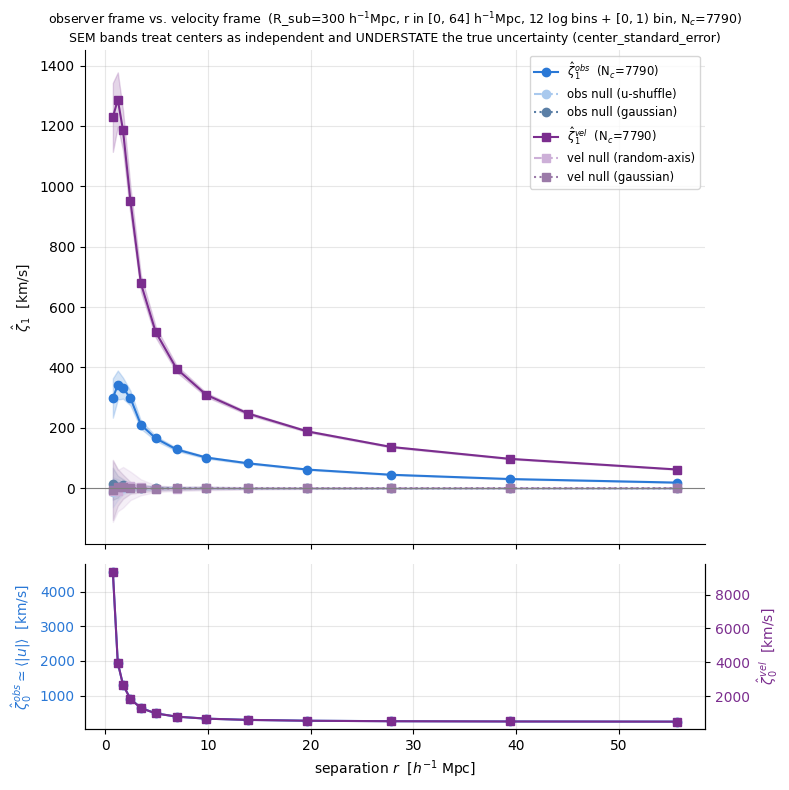

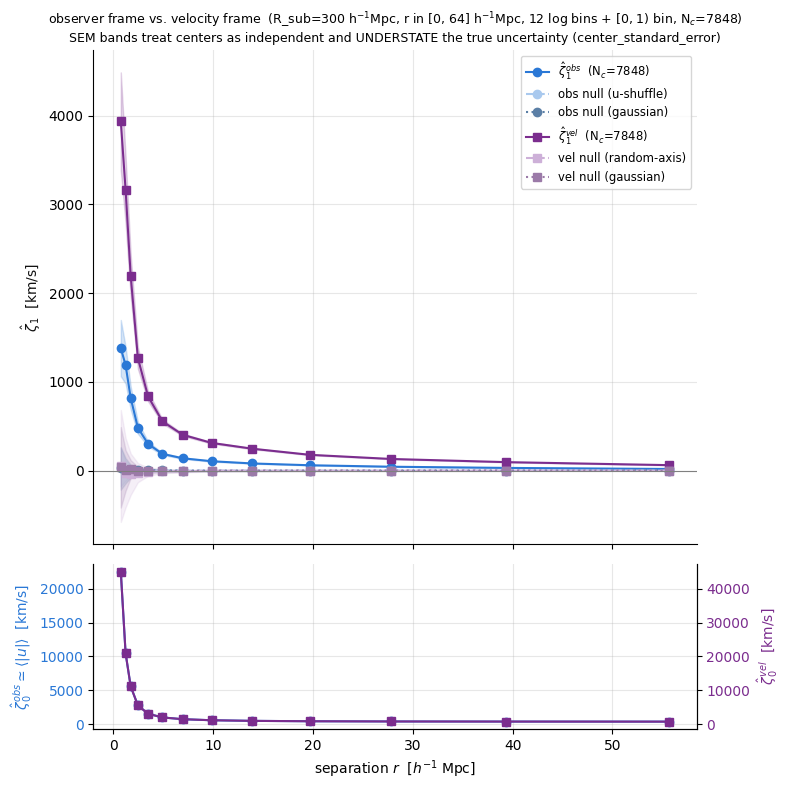

In [6]:
frame_figs = {
    center_class: make_comparison_figure(cfg, run.results, run.comparison)
    for center_class, run in frame_runs.items()
}

### 3b — The class contrast

Four ζ̂₁ curves, {obs, vel} × {parent, subhalo}, with across-center SEM error bars. **Color is
the frame** (blue observer, purple velocity — the identical hues notebook 06 uses, so the two
figures read as one family) and **marker is the class** (filled circle parent, hollow triangle
subhalo). Class is deliberately *not* carried by linestyle: dashed and dotted already mean
"null curve" everywhere else in this project, and reusing them for a signal curve here would
make the figure families contradict each other.

**No null curves.** They are on the per-class figures above; reproducing eight of them here
would leave twelve curves on one axis and bury the single comparison this figure exists to
make.

**Check the monopole panel first.** Parents live in denser environments and will show the
higher shell occupancy regardless of any velocity effect — so before reading a dipole gap as
orbital contamination, confirm how much of it the occupancy difference already accounts for.
The panel is twinned (obs left, vel right) for the same reason notebook 06's is: the two
frames' monopoles sit near ⟨|u|⟩ and ⟨|v|⟩ respectively, a projection factor apart, and one
shared axis would compress the smaller and hide the r-dependent trend.

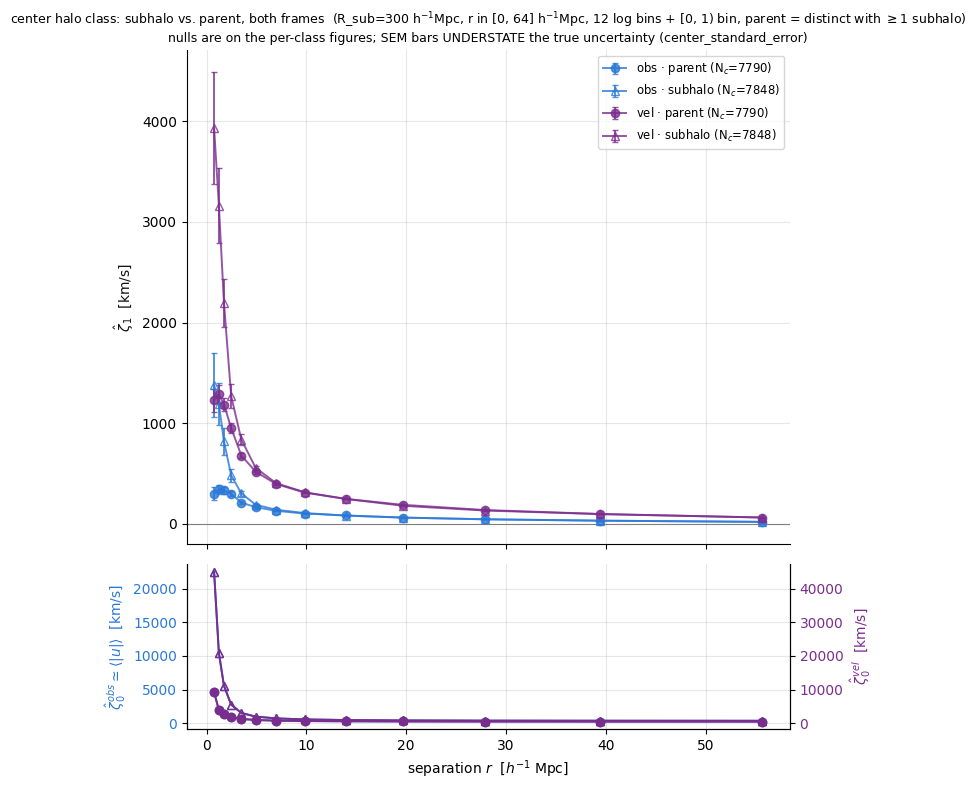

In [7]:
fig_frame_contrast = make_frame_class_contrast_figure(cfg, frame_runs)

### 3c — What the two classes' neighborhoods actually look like, at sub-Mpc scales

The contrast figure above says *"check the monopole panel first"* — but the monopole panel
only reaches down to the innermost estimator shell, and by construction the interesting
difference between a satellite and a host lives **inside** that shell. This histogram goes
there: the average number of tracer halos per shell, across each class's centers, on a
binning of its own —

    [0, 0.1), [0.1, 0.2), ... [0.9, 1.0]   h^-1 Mpc

ten equal shells, the whole ladder sitting inside the run's first dipole bin. It is
`cfg.occupancy_shells`, a **separate** `ShellConfig` from `cfg.shells`, deliberately not
derived from it: the estimator's binning is free to be re-tuned without silently re-binning
this figure.

**Velocities never enter.** This is the pure counting geometry — `per_center_shell_counts`
with the same `np.digitize` semantics and the same `r > 0` self-pair exclusion the estimators
use, so a count here and a `per_center_count` there are the same number. The self-pair
exclusion is load-bearing for once: the first shell starts at zero, every center is itself a
member of the tracer field, and without the cut each center would donate a spurious +1 to a
bin whose true occupancy may be well under 1.

**Tracers are the full carve**, exactly as in the runs above: the neighbors being counted are
every halo in the sub-volume, not the class's own.

The dashed line is `n̄ V_b`, what the same shell would hold in a uniform field at the cosmic
mean density. The ratio of a bar to it is `1 + ξ_hh(r)` averaged over the shell, so on these
scales the bars are a direct picture of the **one-halo term** — how much collapsed structure
each class is sitting in. That is the number to weigh against §5's class ratios before
attributing any of the dipole gap to orbital velocity.

In [8]:
occupancies = class_shell_occupancy_for_runs(cfg, frame_runs, carved.pos, n_bar)

occupancy_edges = cfg.occupancy_shells.shell_edges
expected = next(iter(occupancies.values())).expected_count

header = f"{'shell [h^-1 Mpc]':>18}  {'n_bar*V_b':>10}"
for center_class in occupancies:
    header += f"  {center_class + ' <N>':>22}"
print(header)
for b in range(occupancy_edges.size - 1):
    row = f"[{occupancy_edges[b]:.1f}, {occupancy_edges[b + 1]:.1f})".rjust(18)
    row += f"  {expected[b]:>10.4f}"
    for occupancy in occupancies.values():
        row += f"  {occupancy.mean_count[b]:>11.3f} ± {occupancy.sem_count[b]:<8.3f}"
    print(row)

print()
print("<N> / (n_bar * V_b)  =  1 + xi_hh(r) averaged over the shell")
for center_class, occupancy in occupancies.items():
    ratios = occupancy.mean_count / occupancy.expected_count
    print(f"{center_class:>8}: " + "  ".join(f"{x:8.1f}" for x in ratios))

print()
for center_class, occupancy in occupancies.items():
    print(f"{center_class:>8}: {occupancy.mean_count.sum():8.2f} tracers within "
          f"1 h^-1 Mpc of the average center  (N_c = {occupancy.n_centers:,})")

  shell [h^-1 Mpc]   n_bar*V_b              parent <N>             subhalo <N>
        [0.0, 0.1)      0.0005        0.472 ± 0.007           0.264 ± 0.006   
        [0.1, 0.2)      0.0037        0.744 ± 0.009           0.795 ± 0.011   
        [0.2, 0.3)      0.0101        0.665 ± 0.011           1.262 ± 0.016   
        [0.3, 0.4)      0.0197        0.748 ± 0.014           1.772 ± 0.022   
        [0.4, 0.5)      0.0325        0.835 ± 0.015           2.311 ± 0.028   
        [0.5, 0.6)      0.0486        0.943 ± 0.017           2.823 ± 0.036   
        [0.6, 0.7)      0.0678        1.031 ± 0.019           3.218 ± 0.042   
        [0.7, 0.8)      0.0902        1.118 ± 0.020           3.539 ± 0.048   
        [0.8, 0.9)      0.1158        1.206 ± 0.022           3.886 ± 0.053   
        [0.9, 1.0)      0.1446        1.330 ± 0.024           4.081 ± 0.058   

<N> / (n_bar * V_b)  =  1 + xi_hh(r) averaged over the shell
  parent:    885.1     199.2      65.6      37.9      25.6      19.4 

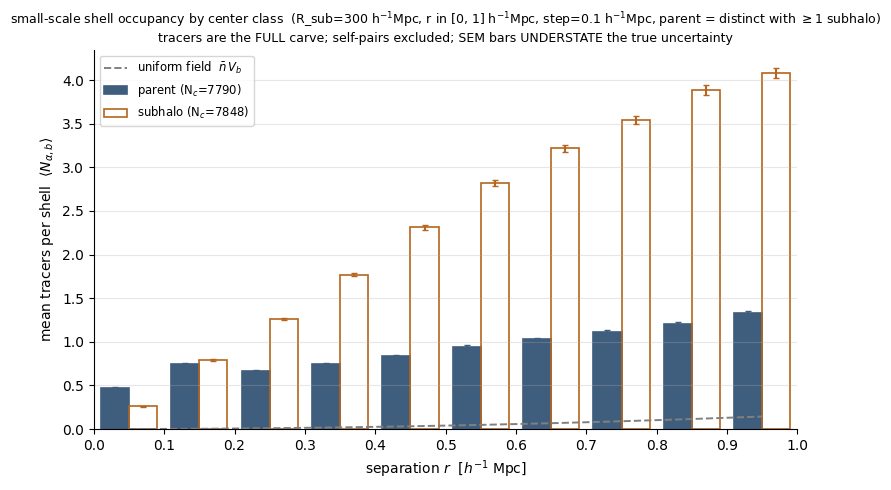

In [9]:
fig_occupancy = make_class_occupancy_figure(cfg, occupancies)

## 4 — Real space vs. redshift space, once per class

The same shape, with notebook 07's center-selection stage in place of the plain one:
candidates come from the **core** carve (a candidate center must be a real member of the
analysis sub-volume, not merely of the wider tracer buffer), and
`select_redshift_shared_centers` applies the widened `r_max + v_margin` real-position margin,
the optional global |v_r| cut, and the through-observer flip guard — all unchanged.

`tracers` is shared across both classes, built once in step 1.

In [10]:
redshift_runs = {
    center_class: run_redshift_comparison_for_class(
        cfg, center_class, buffer, tracers, observer, n_bar
    )
    for center_class in cfg.center_classes
}

print()
for center_class, run in redshift_runs.items():
    print(f"{center_class:>8}: {run.centers.n_centers:>6,} centers  "
          f"(v_r cut dropped {run.centers.n_dropped_v_r_percentile}, "
          f"flip guard dropped {run.centers.n_dropped_flip})")


--- redshift-space comparison, centers = parent ---
class filter -> parent: 570,453 of 14,418,601 carved halos (3.96%)


n_candidates = 16000 -> core cut (core_margin = 105.07859181604672) -> n_core = 4475 (28.0% survive) -> speed floor (min_center_speed = 1.0 km/s) -> n_centers = 4475 (0 dropped as too slow)
redshift-space center selection: base n_centers = 4475 (core_margin = r_max + v_margin = 105.08 h^-1 Mpc) -> global |v_r| <= 4107.9 km/s cut drops 0 -> through-observer guard drops 0 -> n_centers = 4475



--- redshift-space comparison, centers = subhalo ---


class filter -> subhalo: 1,740,627 of 14,418,601 carved halos (12.07%)


n_candidates = 16000 -> core cut (core_margin = 105.07859181604672) -> n_core = 4440 (27.8% survive) -> speed floor (min_center_speed = 1.0 km/s) -> n_centers = 4440 (0 dropped as too slow)
redshift-space center selection: base n_centers = 4440 (core_margin = r_max + v_margin = 105.08 h^-1 Mpc) -> global |v_r| <= 4107.9 km/s cut drops 0 -> through-observer guard drops 0 -> n_centers = 4440



  parent:  4,475 centers  (v_r cut dropped 0, flip guard dropped 0)
 subhalo:  4,440 centers  (v_r cut dropped 0, flip guard dropped 0)


### 4a — Each class's own figure, nulls and all

`redshift_space_comparison.make_redshift_comparison_figure` unchanged, once per class —
notebook 07's figure restricted to one center class.

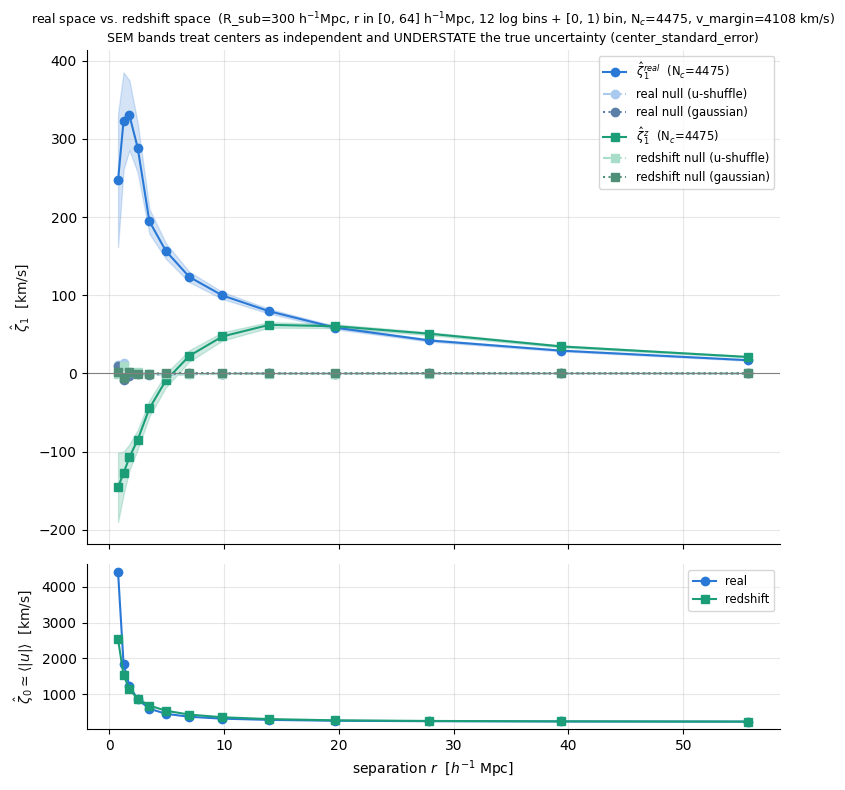

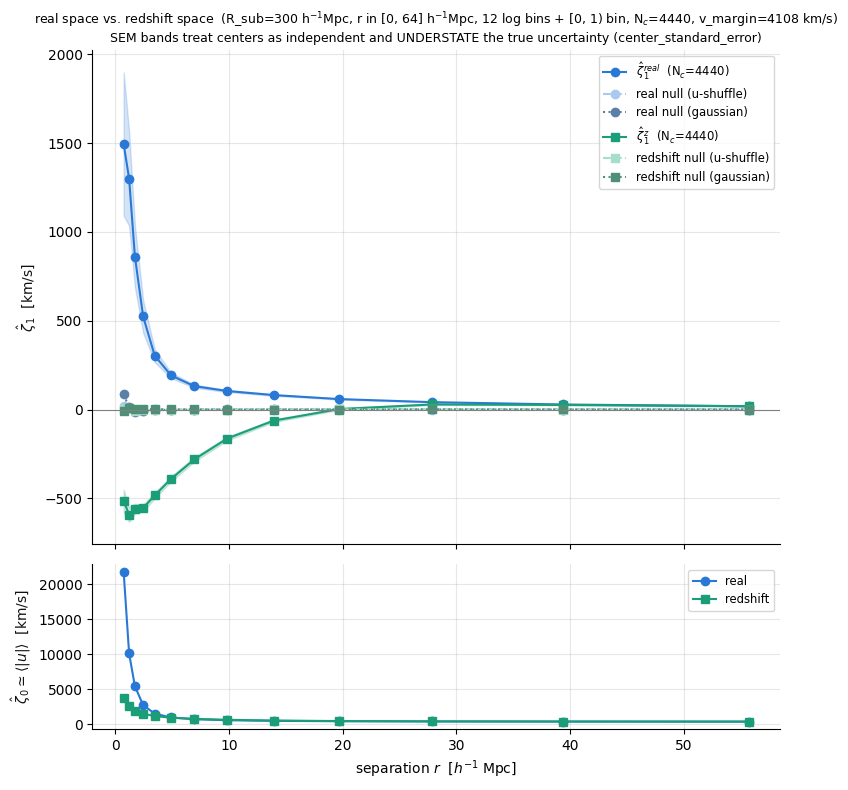

In [11]:
redshift_figs = {
    center_class: make_redshift_comparison_figure(cfg, run.results, run.comparison)
    for center_class, run in redshift_runs.items()
}

### 4b — The class contrast

Four ζ̂₁ curves, {real, redshift} × {parent, subhalo}. Color is the **space** (blue real,
green redshift — notebook 07's hues), marker is the **class**, nulls omitted.

The quantity of interest here is a **ratio of ratios** rather than any single curve: how much
redshift-space distortion costs *each* class. If the redshift/real gap is wider for subhalos
than for parents, the extra loss is the satellites' own orbital velocity smearing them along
the line of sight — the finger-of-God effect reaching the estimator through the center
positions. That is a genuinely different mechanism from the dilution the frame contrast
measures, and it is the reason both comparisons are worth running rather than just one.

The monopole panel here uses a **single shared** y-axis, unlike the frame contrast's twinned
pair: both spaces weight by the same |u_α| on the same centers (n̂ invariance — a displaced
center's line of sight is the same line, so u is unchanged), so the two monopoles are the same
kind of quantity and differ only through shell occupancy. Any trend difference is occupancy
alone, which is exactly the redshift-space trust diagnostic.

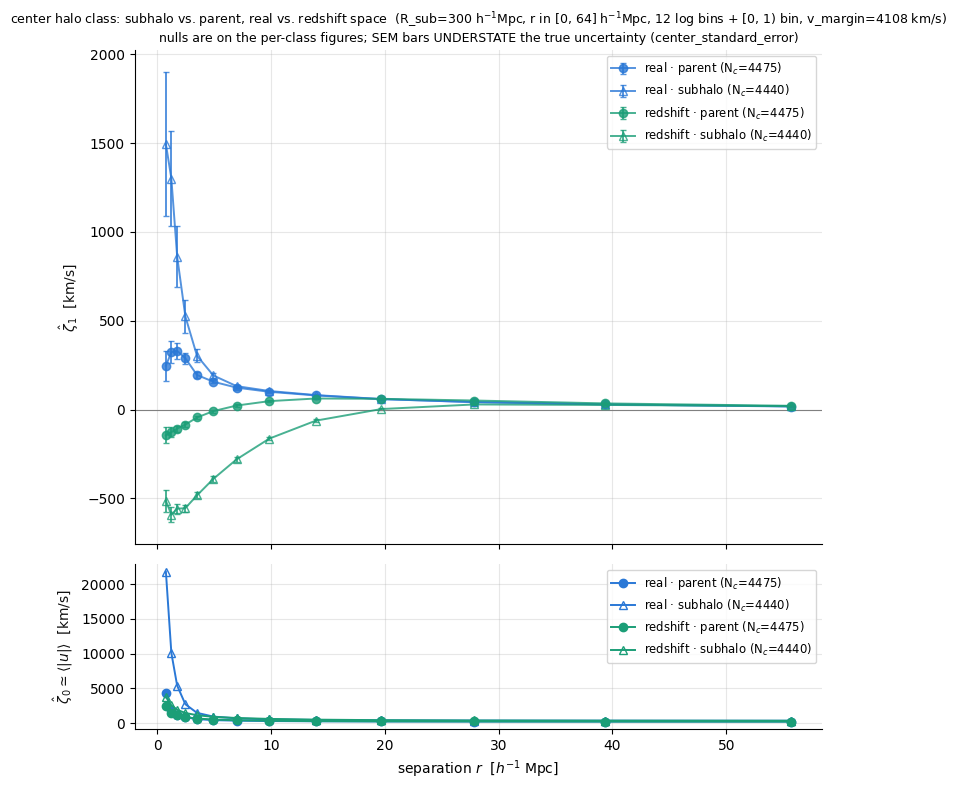

In [12]:
fig_redshift_contrast = make_redshift_class_contrast_figure(cfg, redshift_runs)

## 5 — Summary numbers

The shell-averaged amplitudes, the class ratios (the headline numbers this notebook exists to
produce), and the redshift/real ratio *within* each class.

`|ζ̂₁|` is averaged over shells with `np.nanmean` on the absolute value, matching how the
earlier notebooks report a single amplitude per curve. The ratios are the quantities to carry
forward; the individual amplitudes depend on binning and normalization in ways the ratios
largely divide out.

In [13]:
def amplitude(normalized) -> float:
    "Shell-averaged |zeta_hat_1|, the single-number summary of a curve."
    return float(np.nanmean(np.abs(normalized.zeta_hat)))


print("shell-averaged |zeta_hat_1|  [km/s]")
print(f"{'class':>10}  {'N_c':>7}  {'obs':>9}  {'vel':>9}  {'real':>9}  {'redshift':>9}  {'z/real':>7}")
for center_class in cfg.center_classes:
    frame, redshift = frame_runs[center_class], redshift_runs[center_class]
    a_real = amplitude(redshift.comparison.real)
    a_redshift = amplitude(redshift.comparison.redshift)
    print(f"{center_class:>10}  {frame.centers.n_centers:>7,}  "
          f"{amplitude(frame.comparison.obs):>9.2f}  {amplitude(frame.comparison.vel):>9.2f}  "
          f"{a_real:>9.2f}  {a_redshift:>9.2f}  "
          f"{a_redshift / a_real if a_real else np.nan:>7.3f}")

if len(cfg.center_classes) == 2:
    first, second = cfg.center_classes
    print()
    print(f"class ratios ({first} / {second}):")
    for label, runs, curve in (
        ("obs frame     ", frame_runs, "obs"),
        ("vel frame     ", frame_runs, "vel"),
        ("real space    ", redshift_runs, "real"),
        ("redshift space", redshift_runs, "redshift"),
    ):
        top = amplitude(getattr(runs[first].comparison, curve))
        bottom = amplitude(getattr(runs[second].comparison, curve))
        print(f"  {label}: {top / bottom if bottom else np.nan:6.3f}")
    print()
    print(f"A ratio > 1 means {first}-centered runs carry the larger dipole, which is the")
    print("expected direction if satellite orbital velocity dilutes the signal. Compare each")
    print("ratio against the monopole panels first: some of it is shell occupancy, and some of")
    print("it is the mass difference between the classes, neither of which is dilution.")

shell-averaged |zeta_hat_1|  [km/s]
     class      N_c        obs        vel       real   redshift   z/real
    parent    7,790     162.53     560.39     153.00      62.90    0.411
   subhalo    7,848     372.42    1029.64     395.37     282.82    0.715

class ratios (parent / subhalo):
  obs frame     :  0.436
  vel frame     :  0.544
  real space    :  0.387
  redshift space:  0.222

A ratio > 1 means parent-centered runs carry the larger dipole, which is the
expected direction if satellite orbital velocity dilutes the signal. Compare each
ratio against the monopole panels first: some of it is shell occupancy, and some of
it is the mass difference between the classes, neither of which is dilution.
